# Movilidad y sostenibilidad ambiental en Londres
### *Trabajo final · Ciudades Inteligentes*

**Autores y NIA:**
- Emilio Hermosa Schiantarelli (100451150)
- Carlos Sanchez Arroyo (100451282)
- Rodrigo Valderrey Tarrero (100451271)

**Curso:** 2025/2026

---

## Índice

1. [Carga de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
   - 2.1 Visión general de la calidad del aire
   - 2.2 Valores nulos e imputación
   - 2.3 Distribuciones y outliers
   - 2.4 Red de transporte TfL
3. [Análisis de contaminación del aire](#3)
   - 3.1 Estacionalidad: patrones horarios y estacionales
   - 3.2 Tendencia interanual
   - 3.3 Comparativa entre estaciones
4. [Análisis de movilidad urbana](#4)
   - 4.1 Grafo de la red TfL (RQ4-B)
   - 4.2 Densidad y cobertura de paradas
5. [Integración movilidad-contaminación](#5)
   - 5.1 Descomposición estacional
   - 5.2 Correlación movilidad-contaminación
6. [Modelos predictivos](#6)
   - 6.1 XGBoost: predicción de NO₂
   - 6.2 Proceso Gaussiano: predicción de serie temporal
7. [Representación geográfica (RQ5)](#7)
8. [Dashboard interactivo (RQ3)](#8)

---

## Pregunta de investigación

> **¿Cuál es la relación entre la infraestructura de transporte público y los niveles de contaminación del aire en Londres?**
>
> En particular, buscamos analizar qué estaciones presentan simultáneamente:
>
> - **mayor riesgo ambiental**, asociado a niveles elevados de contaminación;
> - **menor cobertura de transporte público**, medida a partir de la proximidad y densidad de paradas TfL.


La pregunta que planteamos es si las zonas con peor acceso al transporte público presentan también peores niveles de contaminación del aire. Hemos considerado que es relevante por dos razones principales:

- La contaminación atmosférica afecta a la salud, la calidad de vida y la sostenibilidad de la ciudad. 
- La cobertura del transporte público condiciona la accesibilidad, los patrones de movilidad y, potencialmente, la dependencia del vehículo privado. 

Así pues, estudiar la relación entre ambos factores puede permitir identificar zonas urbanas más vulnerables y entender mejor dónde podrían ser más necesarias medidas de planificación del transporte o incluso de intervención ambiental.

Así pues, consideramos que el presente trabajo cumple los requisitos debido a las siguientes razones:

- Usa una ciudad real y datos abiertos de Londres, cumpliendo RQ1
- Integra movilidad y sostenibilidad ambiental, cumpliendo RQ2
- Permite trabajar con series temporales, redes de transporte y representación geográfica, cumpliendo con RQ4 y RQ5
- Sus resultados pueden resumirse de forma natural en un dashboard interactivo, como pide RQ3

## Carga de librerías

Se importan todas las dependencias. Si algún paquete no está disponible se instala automáticamente.

In [6]:
! pip install numpy pandas matplotlib seaborn folium branca geopandas mapclassify h3pandas h3 networkx statsmodels scikit-learn xgboost torch gpytorch --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import warnings, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
for pkg, pkg_install in [('folium','folium'),('gpytorch','gpytorch'),
                          ('branca','branca'),('geopandas','geopandas'),
                          ('mapclassify','mapclassify'),('h3pandas','h3pandas')]:
    if importlib.util.find_spec(pkg) is None:
        import subprocess; subprocess.run(['pip','install',pkg_install,'-q'], check=False)

import folium
from folium.plugins import MarkerCluster, HeatMap
import branca.colormap as cm_folium
import networkx as nx
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import torch, gpytorch
from gpytorch.models import ExactGP
from gpytorch.means import ConstantMean
from gpytorch.kernels import ScaleKernel, RBFKernel
from gpytorch.distributions import MultivariateNormal
from gpytorch.likelihoods import GaussianLikelihood

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 100})
print('Librerías cargadas correctamente.')
import h3pandas
import h3


Librerías cargadas correctamente.


## 1. Carga de datos <a id='1'></a>

| Dataset | Fuente | Descripción |
|---------|--------|-------------|
| LAQN — NO₂, O₃ | London Air Quality Network API | Mediciones horarias 2019-2023, 5 estaciones |
| TfL stops | TfL Open Data GTFS | 4 084 paradas con coordenadas |
| GTFS pathways | TfL Open Data | 5 100 conexiones entre paradas |

Las estaciones LAQN cubren un gradiente urbano completo: desde vías muy transitadas (MY1 = Marylebone Road, WM6 = Oxford Street) hasta zonas suburbanas (BX1 = Bexley).

In [8]:
DATA_DIR = 'data_london'
DASH_DIR = 'dashboard'
os.makedirs(f'{DASH_DIR}/img',  exist_ok=True)
os.makedirs(f'{DASH_DIR}/maps', exist_ok=True)

STATION_INFO = {
    'MY1': {'name': 'Westminster – Marylebone Rd',   'type': 'Roadside',         'lat': 51.52254,  'lon': -0.15459},
    'KC1': {'name': 'Kensington – North Kensington', 'type': 'Urban Background', 'lat': 51.52105,  'lon': -0.21349},
    'WM6': {'name': 'Westminster – Oxford Street',   'type': 'Roadside',         'lat': 51.51393,  'lon': -0.15279},
    'CT3': {'name': 'Camden – Bloomsbury',           'type': 'Urban Background', 'lat': 51.52185,  'lon': -0.12740},
    'BX1': {'name': 'Bexley – Belvedere West',       'type': 'Suburban',         'lat': 51.49386,  'lon':  0.10612},
}

def load_laqn_station(station):
    path = f'{DATA_DIR}/raw/laqn/{station}/no2_pm25_o3_2019_2024.csv'
    df = pd.read_csv(path)
    df['ReadingDateTime'] = pd.to_datetime(df['ReadingDateTime'], format='%d/%m/%Y %H:%M')
    wide = {}
    for sp in df['Species'].unique():
        s = df[df['Species'] == sp].set_index('ReadingDateTime')['Value']
        s = s[~s.index.duplicated(keep='first')]
        if s.notna().mean() > 0.01:  # excluir especies con >99% nulos
            wide[sp] = s
    return pd.DataFrame(wide)

dfs_raw = {s: load_laqn_station(s) for s in STATION_INFO}

no2_raw = pd.DataFrame({s: dfs_raw[s]['NO2'] for s in STATION_INFO})
o3_raw  = pd.DataFrame({s: dfs_raw[s]['O3']  for s in STATION_INFO
                         if 'O3' in dfs_raw[s].columns})
no2_raw = no2_raw.sort_index().asfreq('h')
o3_raw  = o3_raw.sort_index().asfreq('h')

stops         = pd.read_csv(f'{DATA_DIR}/metadata/tfl_geo_stops.csv').dropna(subset=['stop_lat','stop_lon'])
gtfs_stops    = pd.read_csv(f'{DATA_DIR}/raw/tfl/tfl_stationdata_gtfs/stops.txt')
gtfs_pathways = pd.read_csv(f'{DATA_DIR}/raw/tfl/tfl_stationdata_gtfs/pathways.txt')
gtfs_stations = gtfs_stops[gtfs_stops['location_type'] == 1].copy()

print(f'NO2  crudo : {no2_raw.shape[0]:,} horas × {no2_raw.shape[1]} estaciones')
print(f'O3   crudo : {o3_raw.shape[0]:,} horas × {o3_raw.shape[1]} estaciones')
print(f'Período    : {no2_raw.index[0].date()} → {no2_raw.index[-1].date()}')
print(f'Paradas TfL: {len(stops):,}')
print(f'Hubs GTFS  : {len(gtfs_stations)}')
print(f'Pathways   : {len(gtfs_pathways):,}')

NO2  crudo : 43,824 horas × 5 estaciones
O3   crudo : 43,824 horas × 3 estaciones
Período    : 2019-01-01 → 2023-12-31
Paradas TfL: 4,084
Hubs GTFS  : 509
Pathways   : 5,100


## 2. Análisis Exploratorio (EDA) <a id='2'></a>

El EDA sigue la metodología de los laboratorios del curso: estadísticos descriptivos, análisis de nulos, imputación y detección de outliers.

### 2.1 Visión general de la calidad del aire

Examinamos la forma del dataset, tipos de datos y estadísticos básicos de NO₂.

In [9]:
print('=' * 60)
print(f'{"DATOS LAQN — NO₂ (2019-2023)":^60}')
print('=' * 60)
print(f'Dimensiones NO2 : {no2_raw.shape[0]:,} horas × {no2_raw.shape[1]} estaciones')
print(f'Dimensiones O3  : {o3_raw.shape[0]:,} horas × {o3_raw.shape[1]} estaciones')
print(f'Período         : {no2_raw.index[0].date()} → {no2_raw.index[-1].date()}')
print(f'Frecuencia      : {no2_raw.index.freq}')
print('\nEstadísticas del NO₂ (μg/m³):')
display(no2_raw.describe().round(2))

                DATOS LAQN — NO₂ (2019-2023)                
Dimensiones NO2 : 43,824 horas × 5 estaciones
Dimensiones O3  : 43,824 horas × 3 estaciones
Período         : 2019-01-01 → 2023-12-31
Frecuencia      : <Hour>

Estadísticas del NO₂ (μg/m³):


,MY1,KC1,WM6,CT3,BX1
count,41961.00,42199.00,42532.00,38172.00,42375.00
mean,46.57,19.87,38.49,24.88,18.75
std,24.73,16.32,22.59,16.60,16.12
min,0.80,0.00,0.80,0.30,-2.70
25%,27.30,8.40,21.30,12.68,7.30
50%,43.60,14.60,34.40,20.40,13.30
75%,62.10,26.50,51.60,33.00,25.20
max,197.90,191.70,193.90,133.90,128.30


### 2.2 Valores nulos e imputación

La red LAQN tiene gaps de medición por mantenimiento, fallos de sensor y eventos especiales (COVID-19). Aplicamos una estrategia en dos pasos:

1. **Interpolación temporal** (`limit=48 h`): cubre cortes de hasta 2 días.
2. **Media estacional** (hora × mes): para gaps más largos.

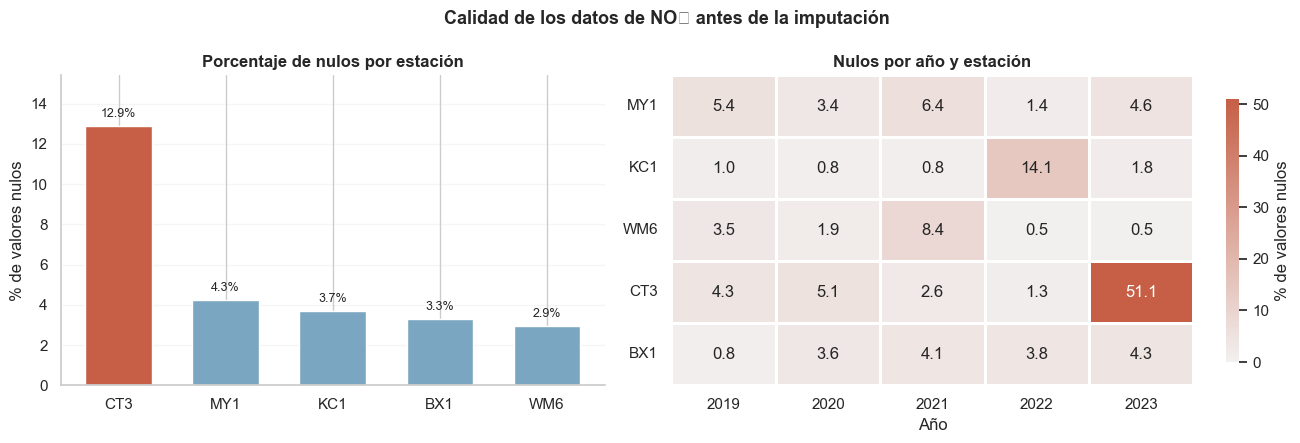

Nulos por estación:
  CT3 (Urban Background    ):  12.9%
  MY1 (Roadside            ):   4.3%
  KC1 (Urban Background    ):   3.7%
  BX1 (Suburban            ):   3.3%
  WM6 (Roadside            ):   2.9%

Nulos tras imputación — NO2: 0
Nulos tras imputación — O3 : 0


In [10]:
null_pct = no2_raw.isna().mean().mul(100).sort_values(ascending=False)
yearly_null = no2_raw.resample('YE').apply(lambda x: x.isna().mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), gridspec_kw={'width_ratios': [1, 1.2]})

bar_colors = ['#c65f46'] + ['#7aa6c2'] * (len(null_pct) - 1)
bars = axes[0].bar(null_pct.index, null_pct.values, color=bar_colors, width=0.62)
axes[0].set_title('Porcentaje de nulos por estación', fontweight='bold')
axes[0].set_ylabel('% de valores nulos')
axes[0].set_xlabel('')
axes[0].set_ylim(0, max(15, null_pct.max() + 2.5))
axes[0].grid(axis='y', alpha=0.18)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, value in zip(bars, null_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value + 0.3,
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(
    yearly_null.T,
    ax=axes[1],
    cmap=sns.light_palette('#c65f46', as_cmap=True),
    vmin=0,
    vmax=float(np.nanmax(yearly_null.to_numpy())),
    annot=True,
    fmt='.1f',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': '% de valores nulos', 'shrink': 0.85}
)
axes[1].set_title('Nulos por año y estación', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Año')
axes[1].set_xticklabels(yearly_null.index.year, rotation=0)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Calidad de los datos de NO₂ antes de la imputación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_nulos_no2.png', bbox_inches='tight', dpi=160)
plt.show()

print('Nulos por estación:')
for s, pct in null_pct.items():
    print(f'  {s} ({STATION_INFO[s]["type"]:20s}): {pct:5.1f}%')

# Imputación paso 1: interpolación temporal
no2_filled = no2_raw.interpolate(method='time', limit=48)
o3_filled  = o3_raw.interpolate(method='time', limit=48)

# Imputación paso 2: media estacional (hora × mes)
def seasonal_impute(df):
    out = df.copy()
    out['_h'] = out.index.hour
    out['_m'] = out.index.month
    for col in df.columns:
        grp = out.groupby(['_m','_h'])[col].transform('mean')
        out[col] = out[col].fillna(grp)
    return out.drop(columns=['_h','_m'])

no2_filled = seasonal_impute(no2_filled)
o3_filled  = seasonal_impute(o3_filled)

print(f'\nNulos tras imputación — NO2: {no2_filled.isna().sum().sum()}')
print(f'Nulos tras imputación — O3 : {o3_filled.isna().sum().sum()}')

La calidad de los datos es, en general, buena en las cinco estaciones analizadas. La mayoría presentan porcentajes reducidos de valores ausentes, por debajo del 5%, aunque CT3 destaca con un nivel de nulos mayor, especialmente en 2023, donde se concentra la mayor parte de las ausencias.

Dado que los valores ausentes se concentran en periodos concretos y no afectan de igual forma a todas las estaciones, aplicamos una estrategia de imputación en dos etapas:
- interpolación temporal para huecos cortos,
- media estacional para faltantes más largos.

Tras este proceso, el número de nulos se reduce a 0 tanto en NO₂ como en O₃.

### 2.3 Distribuciones y tratamiento de outliers

Analizamos las distribuciones de NO₂ por estación para detectar outliers con el criterio IQR. La línea verde marca el **límite anual OMS de 40 μg/m³** para NO₂.

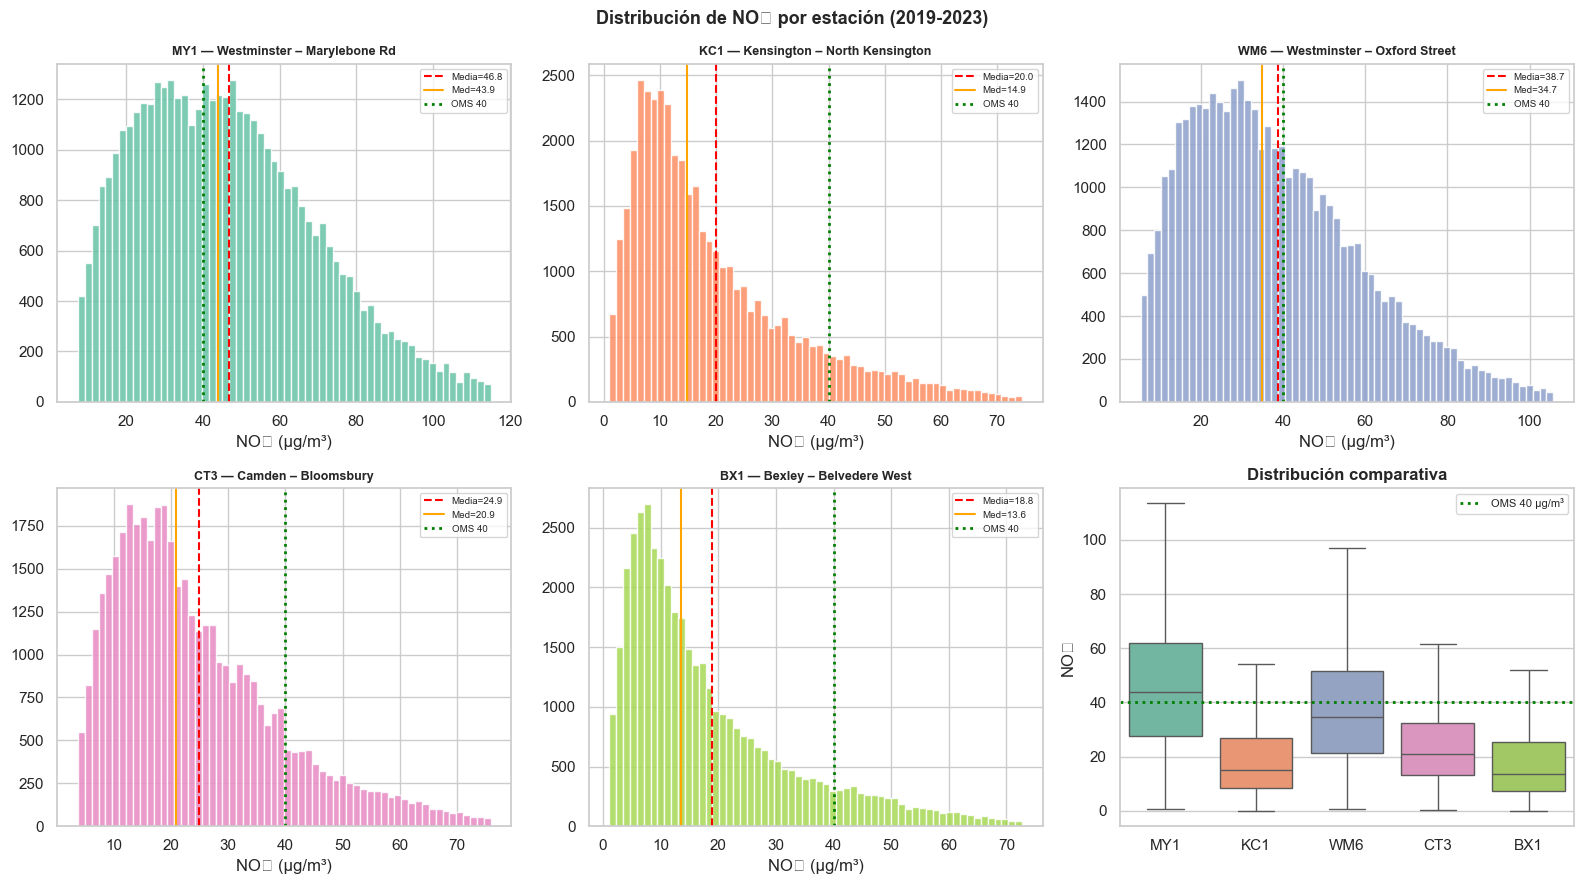

Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR):
  MY1:  450 outliers (1.1%) | rango válido: [-24.9, 114.3]
  KC1: 2159 outliers (5.1%) | rango válido: [-18.8, 53.7]
  WM6:  770 outliers (1.8%) | rango válido: [-24.2, 97.1]
  CT3: 1245 outliers (3.3%) | rango válido: [-17.8, 63.5]
  BX1: 2224 outliers (5.2%) | rango válido: [-19.5, 52.0]


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()
colors = sns.color_palette('Set2', len(STATION_INFO))

for i, (s, info) in enumerate(STATION_INFO.items()):
    data = no2_filled[s]
    q_lo, q_hi = data.quantile(0.01), data.quantile(0.99)
    axes_flat[i].hist(data[(data>=q_lo)&(data<=q_hi)], bins=60,
                      color=colors[i], edgecolor='white', alpha=0.85)
    axes_flat[i].axvline(data.mean(),   color='red',    ls='--',
                         label=f'Media={data.mean():.1f}')
    axes_flat[i].axvline(data.median(), color='orange', ls='-',
                         label=f'Med={data.median():.1f}')
    axes_flat[i].axvline(40, color='green', ls=':', lw=2, label='OMS 40')
    axes_flat[i].set_title(f'{s} — {info["name"]}', fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel('NO₂ (μg/m³)')
    axes_flat[i].legend(fontsize=7)

# Último panel: boxplot comparativo
data_bp = pd.melt(no2_filled.clip(lower=0), var_name='Est.', value_name='NO₂')
sns.boxplot(data=data_bp, x='Est.', y='NO₂', ax=axes_flat[5],
            palette='Set2', showfliers=False)
axes_flat[5].axhline(40, color='green', ls=':', lw=2, label='OMS 40 μg/m³')
axes_flat[5].set_title('Distribución comparativa', fontweight='bold')
axes_flat[5].set_xlabel('')
axes_flat[5].legend(fontsize=8)

plt.suptitle('Distribución de NO₂ por estación (2019-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DASH_DIR}/img/fig_distribuciones.png', bbox_inches='tight')
plt.show()

print('Outliers IQR (fuera de Q1−1.5×IQR, Q3+1.5×IQR):')
for s in STATION_INFO:
    q1, q3 = no2_raw[s].quantile(0.25), no2_raw[s].quantile(0.75)
    iqr = q3 - q1
    mask = (no2_raw[s] < q1-1.5*iqr) | (no2_raw[s] > q3+1.5*iqr)
    n_out = mask.sum()
    pct = n_out / no2_raw[s].notna().sum() * 100
    print(f'  {s}: {n_out:4d} outliers ({pct:.1f}%) | '
          f'rango válido: [{q1-1.5*iqr:.1f}, {q3+1.5*iqr:.1f}]')

no2_clip = no2_filled.clip(lower=0, upper=no2_filled.quantile(0.995).max())

Las distribuciones de NO₂ muestran diferencias claras entre estaciones. 
- MY1 y WM6, ambas de tipo *roadside*, presentan niveles más altos y una mayor proporción de observaciones cercanas o superiores al umbral anual de la OMS (40 μg/m³)
- KC1, CT3 y BX1 se sitúan en valores generalmente más bajos. 

Es importante fijarse en que en casi todas las estaciones la media supera a la mediana, lo que sugiere distribuciones asimétricas a la derecha, con episodios puntuales de contaminación elevada.


### 2.4 Red de transporte TfL

Exploramos la distribución geográfica y tipológica de las paradas TfL. La distancia a la parada más cercana es un indicador de accesibilidad al transporte.